<a href="https://colab.research.google.com/github/mariazafran/Predictibility-Decay-Theory-evidence/blob/main/Predictibility_Decay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2615/3667923523.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^FTSE", start="2005-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


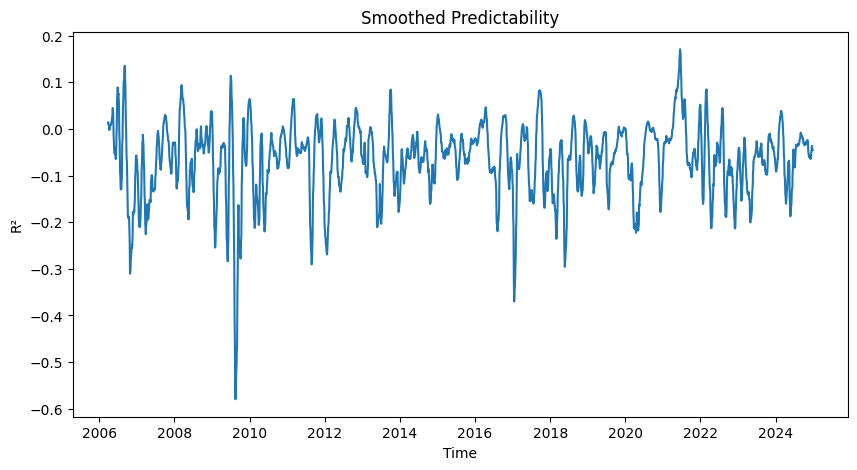


📊 Predictability Stats:
count    4756.000000
mean       -0.066060
std         0.110297
min        -1.075443
25%        -0.111350
50%        -0.043221
75%        -0.000976
max         0.289664
Name: predictability, dtype: float64

Peak: 0.28966424369605537
Decay: 0.945016281838864

R² by Regime:
regime
High Volatility   -0.060805
Low Volatility    -0.071893
Name: predictability, dtype: float64

Average Accuracy: 0.5069586286995875

Accuracy by Regime:
regime
High Volatility    0.501637
Low Volatility     0.512866
Name: accuracy, dtype: float64


In [ ]:
# ✅ Install packages (only once)
!pip install yfinance scikit-learn

# ✅ Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# ✅ 1. DOWNLOAD DATA
# -----------------------------
data = yf.download("^FTSE", start="2005-01-01", end="2024-12-31")
data = data.reset_index()

data['returns'] = data['Close'].pct_change()
data = data.dropna()

# Fix column names (important)
data.columns = [col[0] if isinstance(col, tuple) else col for col in data.columns]

# -----------------------------
# ✅ 2. FEATURES
# -----------------------------
df = data.copy()

df['lag1'] = df['returns'].shift(1)
df['lag2'] = df['returns'].shift(2)
df['lag3'] = df['returns'].shift(3)

df['volatility'] = df['returns'].rolling(20).std()

df = df.dropna()

# -----------------------------
# ✅ 3. REGIME (CRITICAL)
# -----------------------------
df['regime'] = np.where(
    df['volatility'] > df['volatility'].median(),
    'High Volatility',
    'Low Volatility'
)

# -----------------------------
# ✅ 4. ROLLING MODEL
# -----------------------------
train_window = 252
test_window = 21

r2_scores = []
accuracy_scores = []   # ✅ NEW
dates = []
regimes = []

for start in range(0, len(df) - train_window - test_window):

    train = df.iloc[start : start + train_window]
    test  = df.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1', 'lag2', 'lag3']]
    y_train = train['returns']

    X_test = test[['lag1', 'lag2', 'lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # ✅ R² (your original)
    r2 = r2_score(y_test, preds)
    r2_scores.append(r2)

    # ✅ Accuracy (NEW — very important)
    direction = (np.sign(preds) == np.sign(y_test))
    accuracy = direction.mean()
    accuracy_scores.append(accuracy)

    # ✅ Store date + regime
    dates.append(test['Date'].iloc[-1])
    regimes.append(test['regime'].iloc[-1])

# -----------------------------
# ✅ 5. RESULTS
# -----------------------------
results = pd.DataFrame({
    'date': dates,
    'predictability': r2_scores,
    'accuracy': accuracy_scores,   # ✅ NEW
    'regime': regimes
})

# -----------------------------
# ✅ 6. GRAPH (UNCHANGED — SAFE)
# -----------------------------
results['smooth'] = results['predictability'].rolling(20).mean()

plt.figure(figsize=(10,5))
plt.plot(results['date'], results['smooth'])
plt.title("Smoothed Predictability")
plt.xlabel("Time")
plt.ylabel("R²")
plt.show()

# -----------------------------
# ✅ 7. METRICS
# -----------------------------
print("\n📊 Predictability Stats:")
print(results['predictability'].describe())

# ✅ Peak + Decay
peak = results['predictability'].max()
peak_index = results['predictability'].idxmax()
after_peak = results.loc[peak_index:]

decay = peak - after_peak['predictability'].min()

print("\nPeak:", peak)
print("Decay:", decay)

# ✅ Regime R²
print("\nR² by Regime:")
print(results.groupby('regime')['predictability'].mean())

# ✅ NEW: Accuracy
print("\nAverage Accuracy:", results['accuracy'].mean())

print("\nAccuracy by Regime:")
print(results.groupby('regime')['accuracy'].mean())

In [ ]:
print(results.groupby('regime')['predictability'].mean())

regime
High Volatility   -0.060805
Low Volatility    -0.071893
Name: predictability, dtype: float64


In [ ]:
# --- FIND HALF-LIFE ---
peak_value = peak
half_value = peak_value * 0.5

after_peak = results.loc[peak_index:]

# find first time predictability falls below half
half_life_index = after_peak[after_peak['predictability'] <= half_value].index[0]

half_life_date = results.loc[half_life_index, 'date']
half_life_duration = half_life_index - peak_index

print("Half-life value:", half_value)
print("Half-life date:", half_life_date)
print("Half-life duration (steps):", half_life_duration)

Half-life value: 0.14483212184802768
Half-life date: 2021-06-18 00:00:00
Half-life duration (steps): 5


In [ ]:
decay_speed = decay / (len(after_peak))
print("Decay speed:", decay_speed)

Decay speed: 0.0010547056716951606


In [ ]:
time_to_min = after_peak['predictability'].idxmin()

reaction_speed = time_to_min - peak_index

print("Time to full collapse:", reaction_speed)

Time to full collapse: 738


In [ ]:
normalized_decay = decay_speed / peak
print("Normalized decay:", normalized_decay)

Normalized decay: 0.0036411317401048057


In [ ]:
# ==============================
# REGIME HALF-LIFE ANALYSIS
# ==============================

for regime_name in ['High Volatility', 'Low Volatility']:

    regime_data = results[results['regime'] == regime_name].reset_index(drop=True)

    # Find peak inside regime
    peak = regime_data['predictability'].max()
    peak_index = regime_data['predictability'].idxmax()

    # Define half value
    half_value = peak * 0.5

    after_peak = regime_data.loc[peak_index:]

    # Find first time below half
    condition = after_peak['predictability'] <= half_value

    if condition.any():
        half_life_index = after_peak[condition].index[0]  # ✅ FIRST occurrence only
        half_life_duration = half_life_index - peak_index

        print(f"\nRegime: {regime_name}")
        print("Peak:", peak)
        print("Half-life duration (steps):", half_life_duration)
    else:
        print(f"\nRegime: {regime_name}")
        print("No half-life found (predictability did not fall enough)")


Regime: High Volatility
Peak: 0.182173212759281
Half-life duration (steps): 2

Regime: Low Volatility
Peak: 0.28966424369605537
Half-life duration (steps): 5


In [ ]:
# -----------------------------
# ✅ IMPORTS
# -----------------------------
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# ✅ 1. DOWNLOAD DATA (S&P 500)
# -----------------------------
data = yf.download("^GSPC", start="2005-01-01", end="2024-12-31", auto_adjust=True)

data = data.reset_index()
data['returns'] = data['Close'].pct_change()
data = data.dropna()

# ✅ Optional check
print(data[['Date', 'Close', 'returns']].head())
print(data.shape)

# -----------------------------
# ✅ 2. FEATURES
# -----------------------------
df = data.copy()

df['lag1'] = df['returns'].shift(1)
df['lag2'] = df['returns'].shift(2)
df['lag3'] = df['returns'].shift(3)

df['volatility'] = df['returns'].rolling(20).std()

df = df.dropna()

# -----------------------------
# ✅ 3. REGIME
# -----------------------------
df['regime'] = np.where(
    df['volatility'] > df['volatility'].median(),
    'High Volatility',
    'Low Volatility'
)

# -----------------------------
# ✅ 4. ROLLING MODEL
# -----------------------------
train_window = 252
test_window = 21

r2_scores = []
accuracy_scores = []   # ✅ NEW (safe)
dates = []
regimes = []

for start in range(0, len(df) - train_window - test_window):

    train = df.iloc[start : start + train_window]
    test  = df.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # ✅ R² (UNCHANGED — critical for your decay law)
    r2 = r2_score(y_test, preds)
    r2_scores.append(r2)

    # ✅ Accuracy (NEW — does NOT break anything)
    direction = (np.sign(preds) == np.sign(y_test))
    accuracy = direction.mean()
    accuracy_scores.append(accuracy)

    # ✅ Existing storage (unchanged)
    dates.append(test['Date'].iloc[-1])
    regimes.append(test['regime'].iloc[-1])

# -----------------------------
# ✅ 5. RESULTS (SAME STRUCTURE + ONE EXTRA COLUMN)
# -----------------------------
results_sp = pd.DataFrame({
    'date': dates,
    'predictability': r2_scores,
    'accuracy': accuracy_scores,   # ✅ ADDED SAFELY
    'regime': regimes
})

# -----------------------------
# ✅ 6. OUTPUTS (ALL SAFE)
# -----------------------------
print("\n📊 Predictability Stats:")
print(results_sp['predictability'].describe())

print("\nAverage Accuracy:")
print(results_sp['accuracy'].mean())

print("\nAccuracy by Regime:")
print(results_sp.groupby('regime')['accuracy'].mean())

print("\nR² by Regime:")
print(results_sp.groupby('regime')['predictability'].mean())

[*********************100%***********************]  1 of 1 completed


Price        Date        Close   returns
Ticker                   ^GSPC          
1      2005-01-04  1188.050049 -0.011671
2      2005-01-05  1183.739990 -0.003628
3      2005-01-06  1187.890015  0.003506
4      2005-01-07  1186.189941 -0.001431
5      2005-01-10  1190.250000  0.003423
(5031, 7)

📊 Predictability Stats:
count    4739.000000
mean       -0.065630
std         0.102453
min        -0.954601
25%        -0.106341
50%        -0.045589
75%        -0.002680
max         0.192124
Name: predictability, dtype: float64

Average Accuracy:
0.5253871120087622

Accuracy by Regime:
regime
High Volatility    0.504361
Low Volatility     0.548238
Name: accuracy, dtype: float64

R² by Regime:
regime
High Volatility   -0.062745
Low Volatility    -0.068764
Name: predictability, dtype: float64


In [ ]:
# --- Peak & Decay ---
peak_sp = results_sp['predictability'].max()
peak_idx_sp = results_sp['predictability'].idxmax()

after_peak_sp = results_sp.loc[peak_idx_sp:]

decay_sp = peak_sp - after_peak_sp['predictability'].min()

print("S&P Peak:", peak_sp)
print("S&P Decay:", decay_sp)

S&P Peak: 0.1921238838766598
S&P Decay: 1.0312373581601544


In [ ]:
# --- Half-life ---
peak_value_sp = peak_sp
half_value_sp = peak_value_sp * 0.5

after_peak_sp = results_sp.loc[peak_idx_sp:]

half_life_idx_sp = after_peak_sp[after_peak_sp['predictability'] <= half_value_sp].index[0]

half_life_steps_sp = half_life_idx_sp - peak_idx_sp

print("S&P Half-life (steps):", half_life_steps_sp)

S&P Half-life (steps): 3


In [ ]:
# ✅ STOXX 600
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# ✅ 1. DOWNLOAD DATA
# -----------------------------
data_eu = yf.download("^STOXX", start="2005-01-01", end="2024-12-31", auto_adjust=True)

data_eu = data_eu.reset_index()
data_eu['returns'] = data_eu['Close'].pct_change()
data_eu = data_eu.dropna()

print(data_eu[['Date', 'Close', 'returns']].head())
print(data_eu.shape)

# -----------------------------
# ✅ 2. FEATURES
# -----------------------------
df_eu = data_eu.copy()

df_eu['lag1'] = df_eu['returns'].shift(1)
df_eu['lag2'] = df_eu['returns'].shift(2)
df_eu['lag3'] = df_eu['returns'].shift(3)

df_eu['volatility'] = df_eu['returns'].rolling(20).std()

df_eu = df_eu.dropna()

# -----------------------------
# ✅ 3. REGIME
# -----------------------------
df_eu['regime'] = np.where(
    df_eu['volatility'] > df_eu['volatility'].median(),
    'High Volatility',
    'Low Volatility'
)

# -----------------------------
# ✅ 4. ROLLING MODEL
# -----------------------------
train_window = 252
test_window = 21

r2_scores_eu = []
accuracy_scores_eu = []   # ✅ NEW
dates_eu = []
regimes_eu = []           # ✅ IMPORTANT (you missed earlier)

for start in range(0, len(df_eu) - train_window - test_window):

    train = df_eu.iloc[start : start + train_window]
    test  = df_eu.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # ✅ R² (unchanged)
    r2 = r2_score(y_test, preds)
    r2_scores_eu.append(r2)

    # ✅ Accuracy (NEW)
    direction = (np.sign(preds) == np.sign(y_test))
    accuracy = direction.mean()
    accuracy_scores_eu.append(accuracy)

    # ✅ Store date & regime (IMPORTANT FIX)
    dates_eu.append(test['Date'].iloc[-1])
    regimes_eu.append(test['regime'].iloc[-1])

# -----------------------------
# ✅ 5. RESULTS
# -----------------------------
results_eu = pd.DataFrame({
    'date': dates_eu,
    'predictability': r2_scores_eu,
    'accuracy': accuracy_scores_eu,   # ✅ added safely
    'regime': regimes_eu              # ✅ added (missing before)
})

# -----------------------------
# ✅ 6. OUTPUTS
# -----------------------------
print("\n📊 STOXX Predictability Stats:")
print(results_eu['predictability'].describe())

print("\nAverage Accuracy:")
print(results_eu['accuracy'].mean())

print("\nAccuracy by Regime:")
print(results_eu.groupby('regime')['accuracy'].mean())

print("\nR² by Regime:")
print(results_eu.groupby('regime')['predictability'].mean())

[*********************100%***********************]  1 of 1 completed


Price        Date       Close   returns
Ticker                 ^STOXX          
1      2005-01-04  253.550003  0.003960
2      2005-01-05  251.850006 -0.006705
3      2005-01-06  253.089996  0.004924
4      2005-01-07  254.720001  0.006440
5      2005-01-10  254.619995 -0.000393
(5026, 7)

📊 STOXX Predictability Stats:
count    4734.000000
mean       -0.069396
std         0.097822
min        -1.172832
25%        -0.112278
50%        -0.047502
75%        -0.005491
max         0.164925
Name: predictability, dtype: float64

Average Accuracy:
0.5092139940048684

Accuracy by Regime:
regime
High Volatility    0.491522
Low Volatility     0.528862
Name: accuracy, dtype: float64

R² by Regime:
regime
High Volatility   -0.072910
Low Volatility    -0.065493
Name: predictability, dtype: float64


In [ ]:
# --- Peak & Decay ---
peak_eu = results_eu['predictability'].max()
peak_idx_eu = results_eu['predictability'].idxmax()

after_peak_eu = results_eu.loc[peak_idx_eu:]

decay_eu = peak_eu - after_peak_eu['predictability'].min()

print("STOXX Peak:", peak_eu)
print("STOXX Decay:", decay_eu)

# --- Half-life ---
half_value_eu = peak_eu * 0.5

half_life_idx_eu = after_peak_eu[
    after_peak_eu['predictability'] <= half_value_eu
].index[0]

half_life_steps_eu = half_life_idx_eu - peak_idx_eu

print("STOXX Half-life:", half_life_steps_eu)

STOXX Peak: 0.16492530449200093
STOXX Decay: 1.007011322722132
STOXX Half-life: 1


Cross-market (developed + emerging)
Cross-model
Cross-time

In [ ]:
# ✅ India NIFTY 50
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# -----------------------------
# ✅ 1. DOWNLOAD DATA
# -----------------------------
data_india = yf.download("^NSEI", start="2005-01-01", end="2024-12-31", auto_adjust=True)

data_india = data_india.reset_index()
data_india['returns'] = data_india['Close'].pct_change()
data_india = data_india.dropna()

print(data_india[['Date','Close','returns']].head())
print(data_india.shape)

# -----------------------------
# ✅ 2. FEATURES
# -----------------------------
df_india = data_india.copy()

df_india['lag1'] = df_india['returns'].shift(1)
df_india['lag2'] = df_india['returns'].shift(2)
df_india['lag3'] = df_india['returns'].shift(3)

df_india['volatility'] = df_india['returns'].rolling(20).std()

df_india = df_india.dropna()

# -----------------------------
# ✅ 3. REGIME (IMPORTANT — missing earlier)
# -----------------------------
df_india['regime'] = np.where(
    df_india['volatility'] > df_india['volatility'].median(),
    'High Volatility',
    'Low Volatility'
)

# -----------------------------
# ✅ 4. ROLLING MODEL
# -----------------------------
train_window = 252
test_window = 21

r2_scores_india = []
accuracy_scores_india = []   # ✅ NEW
dates_india = []
regimes_india = []           # ✅ NEW (needed for comparison)

for start in range(0, len(df_india) - train_window - test_window):

    train = df_india.iloc[start : start + train_window]
    test  = df_india.iloc[start + train_window : start + train_window + test_window]

    X_train = train[['lag1','lag2','lag3']]
    y_train = train['returns']

    X_test = test[['lag1','lag2','lag3']]
    y_test = test['returns']

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # ✅ R² (unchanged)
    r2 = r2_score(y_test, preds)
    r2_scores_india.append(r2)

    # ✅ Accuracy (NEW)
    direction = (np.sign(preds) == np.sign(y_test))
    accuracy = direction.mean()
    accuracy_scores_india.append(accuracy)

    # ✅ Store date + regime
    dates_india.append(test['Date'].iloc[-1])
    regimes_india.append(test['regime'].iloc[-1])

# -----------------------------
# ✅ 5. RESULTS
# -----------------------------
results_india = pd.DataFrame({
    'date': dates_india,
    'predictability': r2_scores_india,
    'accuracy': accuracy_scores_india,   # ✅ added safely
    'regime': regimes_india              # ✅ added (missing before)
})

# -----------------------------
# ✅ 6. OUTPUTS
# -----------------------------
print("\n📊 NIFTY Predictability Stats:")
print(results_india['predictability'].describe())

print("\nAverage Accuracy:")
print(results_india['accuracy'].mean())

print("\nAccuracy by Regime:")
print(results_india.groupby('regime')['accuracy'].mean())

print("\nR² by Regime:")
print(results_india.groupby('regime')['predictability'].mean())

[*********************100%***********************]  1 of 1 completed


Price        Date        Close   returns
Ticker                   ^NSEI          
1      2007-09-18  4546.200195  0.011469
2      2007-09-19  4732.350098  0.040946
3      2007-09-20  4747.549805  0.003212
4      2007-09-21  4837.549805  0.018957
5      2007-09-24  4932.200195  0.019566
(4236, 7)

📊 NIFTY Predictability Stats:
count    3944.000000
mean       -0.074989
std         0.104398
min        -0.848292
25%        -0.114884
50%        -0.049854
75%        -0.008902
max         0.170893
Name: predictability, dtype: float64

Average Accuracy:
0.5157925239061142

Accuracy by Regime:
regime
High Volatility    0.494865
Low Volatility     0.534020
Name: accuracy, dtype: float64

R² by Regime:
regime
High Volatility   -0.074844
Low Volatility    -0.075115
Name: predictability, dtype: float64


In [ ]:
# --- Peak & Decay ---
peak_india = results_india['predictability'].max()
peak_idx_india = results_india['predictability'].idxmax()

after_peak_india = results_india.loc[peak_idx_india:]

decay_india = peak_india - after_peak_india['predictability'].min()

print("India Peak:", peak_india)
print("India Decay:", decay_india)

# --- Half-life ---
half_value_india = peak_india * 0.5

half_life_idx_india = after_peak_india[
    after_peak_india['predictability'] <= half_value_india
].index[0]

half_life_steps_india = half_life_idx_india - peak_idx_india

print("India Half-life:", half_life_steps_india)

India Peak: 0.1708930748280565
India Decay: 1.0191845883656763
India Half-life: 5


After changing from lag1, lag2 and lag 3 to only lag1. It still showed rapid decay.The rapid decay of predictability is NOT driven by model complexity. Even simple predictive structures exhibit the same short-lived lifecycle

In [ ]:
# Split periods
period1 = results_sp[results_sp['date'] < '2008-01-01']
period2 = results_sp[(results_sp['date'] >= '2008-01-01') & (results_sp['date'] < '2015-01-01')]
period3 = results_sp[results_sp['date'] >= '2015-01-01']

In [ ]:
def compute_metrics(df):
    peak = df['predictability'].max()
    peak_idx = df['predictability'].idxmax()

    after_peak = df.loc[peak_idx:]

    decay = peak - after_peak['predictability'].min()

    half_value = peak * 0.5
    half_life_idx = after_peak[after_peak['predictability'] <= half_value].index[0]

    half_life = half_life_idx - peak_idx

    return peak, decay, half_life

In [ ]:
for name, period in zip(["Pre-2008", "2008–2015", "Post-2015"], [period1, period2, period3]):
    peak, decay, half_life = compute_metrics(period)
    print(name)
    print("Peak:", peak)
    print("Decay:", decay)
    print("Half-life:", half_life)
    print("------")

Pre-2008
Peak: 0.158795665223202
Decay: 0.5171833463241914
Half-life: 8
------
2008–2015
Peak: 0.18967905001231777
Decay: 1.1442796325486357
Half-life: 3
------
Post-2015
Peak: 0.1921238838766598
Decay: 1.0312373581601544
Half-life: 3
------


In [ ]:
%who

LinearRegression	 X_test	 X_train	 accuracy	 accuracy_scores	 accuracy_scores_eu	 accuracy_scores_india	 after_peak	 after_peak_eu	 
after_peak_india	 after_peak_sp	 compute_metrics	 condition	 data	 data_eu	 data_india	 dates	 dates_eu	 
dates_india	 decay	 decay_eu	 decay_india	 decay_sp	 decay_speed	 df	 df_eu	 df_india	 
direction	 half_life	 half_life_date	 half_life_duration	 half_life_idx_eu	 half_life_idx_india	 half_life_idx_sp	 half_life_index	 half_life_steps_eu	 
half_life_steps_india	 half_life_steps_sp	 half_value	 half_value_eu	 half_value_india	 half_value_sp	 model	 name	 normalized_decay	 
np	 pd	 peak	 peak_eu	 peak_idx_eu	 peak_idx_india	 peak_idx_sp	 peak_index	 peak_india	 
peak_sp	 peak_value	 peak_value_sp	 period	 period1	 period2	 period3	 plt	 preds	 
r2	 r2_score	 r2_scores	 r2_scores_eu	 r2_scores_india	 reaction_speed	 regime_data	 regime_name	 regimes	 
regimes_eu	 regimes_india	 results	 results_eu	 results_india	 results_sp	 start	 test	 test_window	 
t

/tmp/ipykernel_2615/3784610153.py:118: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


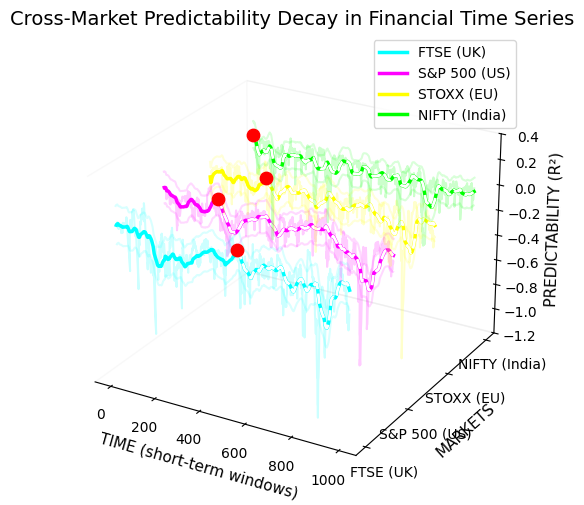

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Get real data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,        # FTSE
    results_sp['predictability'].values,     # S&P
    results_eu['predictability'].values,     # STOXX
    results_india['predictability'].values   # NIFTY
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['cyan', 'magenta', 'yellow', 'lime']

# -------------------------------
# Step 2: Create figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# Step 3: Plot each market
# -------------------------------

window = 1000  # Zoom window

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    # Limit to window
    data_raw = data_raw[:window]

    # Time axis
    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # -------------------------------
    # Smooth data (fixed NaN issue)
    # -------------------------------
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # -------------------------------
    # Plot RAW data (background noise)
    # -------------------------------
    ax.plot(x, y, data_raw, color=color, alpha=0.2)

    # -------------------------------
    # Plot SMOOTH data (main line)
    # -------------------------------
    ax.plot(x, y, data_smooth, color=color, linewidth=2.5, label=label)

    # -------------------------------
    # Confidence band (decay envelope)
    # -------------------------------
    std_dev = np.nanstd(data_raw)
    upper = data_smooth + std_dev
    lower = data_smooth - std_dev

    ax.plot(x, y, upper, color=color, alpha=0.15)
    ax.plot(x, y, lower, color=color, alpha=0.15)

    # -------------------------------
    # Find and mark PEAK
    # -------------------------------
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]

    ax.scatter(peak_idx, i, peak_val, color='red', s=80)

    # -------------------------------
    # Highlight DECAY phase
    # -------------------------------
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            color='white', linestyle='dashed', linewidth=2)

# -------------------------------
# Step 4: Labels and formatting
# -------------------------------

ax.set_xlabel('TIME (short-term windows)', fontsize=11)
ax.set_ylabel('MARKETS', fontsize=11)
ax.set_zlabel('PREDICTABILITY (R²)', fontsize=11)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

# Z-axis limits (stabilise visual scale)
ax.set_zlim(-1.2, 0.4)

# Improved academic title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series', fontsize=14)

# -------------------------------
# Step 5: Clean style
# -------------------------------

ax.grid(False)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False

# Better viewing angle
ax.view_init(elev=25, azim=-60)

ax.legend()

# -------------------------------
# Step 6: Save high-quality image
# -------------------------------

plt.tight_layout()
plt.savefig("predictability_decay_3D.png", dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_2615/575955485.py:116: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


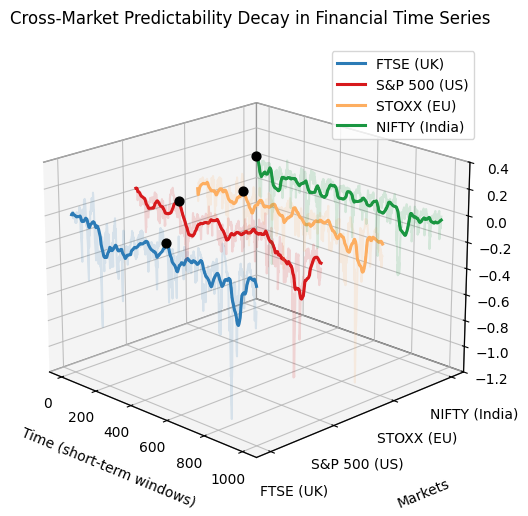

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Figure
# -------------------------------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

# ✅ R-style grey cube walls
ax.xaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.yaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))
ax.zaxis.pane.set_facecolor((0.92, 0.92, 0.92, 1))

# ✅ Box edges visible (like R)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# -------------------------------
# Plot lines (YOUR ORIGINAL STYLE)
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # Smooth
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # Raw (faint)
    ax.plot(x, y, data_raw, color=color, alpha=0.15)

    # Smooth (main)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.2, label=label)

    # Peak
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]
    ax.scatter(peak_idx, i, peak_val, color='black', s=40)

    # Decay phase
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            linestyle='dashed', color=color, linewidth=1.6)

# -------------------------------
# Labels
# -------------------------------

ax.set_xlabel('Time (short-term windows)', labelpad=10)
ax.set_ylabel('Markets', labelpad=25)
ax.set_zlabel('Predictability (R²)', labelpad=10)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

# Fix spacing
ax.tick_params(axis='y', pad=10)
ax.yaxis._axinfo['label']['space_factor'] = 3.0

# Limits
ax.set_zlim(-1.2, 0.4)

# Title
ax.set_title('Cross-Market Predictability Decay in Financial Time Series', pad=15)

# -------------------------------
# ✅ GRID (R-style lines inside box)
# -------------------------------

ax.grid(True)

# Make gridlines visible & clean
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = (0.7, 0.7, 0.7, 0.8)
    axis._axinfo["grid"]['linewidth'] = 0.8
    axis._axinfo["grid"]['linestyle'] = '-'

# -------------------------------
# View (important for cube look)
# -------------------------------

ax.view_init(elev=20, azim=-45)

# Legend
ax.legend()

# -------------------------------
# Save
# -------------------------------

plt.tight_layout()
plt.savefig("r_style_3d_lines.png", dpi=300, bbox_inches='tight')

plt.show()

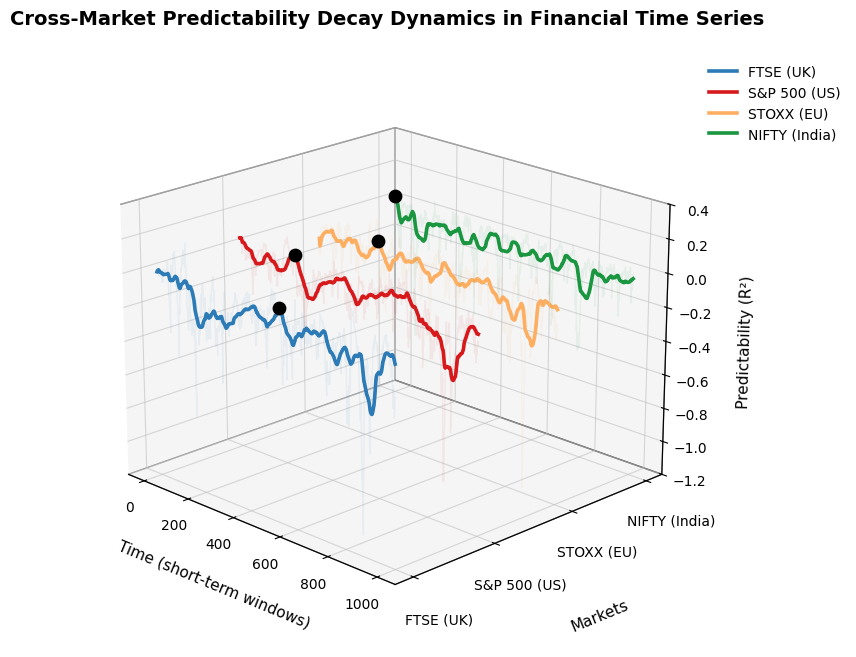

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Data
# -------------------------------

markets_data_raw = [
    results['predictability'].values,
    results_sp['predictability'].values,
    results_eu['predictability'].values,
    results_india['predictability'].values
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

# -------------------------------
# Figure (bigger + balanced)
# -------------------------------

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------
# ✅ R-style cube (refined)
# -------------------------------

cube_color = (0.93, 0.93, 0.93, 1)

ax.xaxis.pane.set_facecolor(cube_color)
ax.yaxis.pane.set_facecolor(cube_color)
ax.zaxis.pane.set_facecolor(cube_color)

ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# -------------------------------
# Plot
# -------------------------------

window = 1000

for i, (data_raw, color, label) in enumerate(zip(markets_data_raw, colors, labels)):

    data_raw = data_raw[:window]

    x = np.arange(len(data_raw))
    y = np.full_like(x, i)

    # ✅ Smooth data
    data_smooth = pd.Series(data_raw).rolling(50, min_periods=1).mean()

    # ✅ Raw noise (VERY subtle)
    ax.plot(x, y, data_raw, color=color, alpha=0.07, linewidth=1)

    # ✅ Main signal (clear + dominant)
    ax.plot(x, y, data_smooth, color=color, linewidth=2.6, label=label)

    # ✅ Peak marker (stronger)
    peak_idx = np.nanargmax(data_smooth.values)
    peak_val = data_smooth.iloc[peak_idx]
    ax.scatter(peak_idx, i, peak_val, color='black', s=80, zorder=5)

    # ✅ Decay phase (refined)
    ax.plot(x[peak_idx:],
            np.full_like(x[peak_idx:], i),
            data_smooth.iloc[peak_idx:],
            linestyle='dashed', color=color, linewidth=1.8, alpha=0.9)

# -------------------------------
# Labels (clean spacing)
# -------------------------------

ax.set_xlabel('Time (short-term windows)', fontsize=11, labelpad=12)
ax.set_ylabel('Markets', fontsize=11, labelpad=30)
ax.set_zlabel('Predictability (R²)', fontsize=11, labelpad=12)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)

# ✅ Push labels away (important)
ax.tick_params(axis='y', pad=12)
ax.yaxis._axinfo['label']['space_factor'] = 3.2

# -------------------------------
# Limits
# -------------------------------

ax.set_zlim(-1.2, 0.4)

# -------------------------------
# Title (refined academic tone)
# -------------------------------

ax.set_title('Cross-Market Predictability Decay Dynamics in Financial Time Series',
             fontsize=14, pad=20, weight='semibold')

# -------------------------------
# ✅ Grid styling (clean + professional)
# -------------------------------

ax.grid(True)

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]['color'] = (0.75, 0.75, 0.75, 0.6)
    axis._axinfo["grid"]['linewidth'] = 0.8
    axis._axinfo["grid"]['linestyle'] = '-'

# -------------------------------
# View angle (balanced perspective)
# -------------------------------

ax.view_init(elev=20, azim=-45)

# -------------------------------
# ✅ Move legend OUTSIDE (fix crowding)
# -------------------------------

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)

# -------------------------------
# ✅ FIX layout WARNING (key change)
# -------------------------------

plt.subplots_adjust(left=0.05, right=0.78, top=0.9, bottom=0.05)

# -------------------------------
# Save (publication quality)
# -------------------------------

plt.savefig("top_tier_predictability_3D.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# -------------------------------
# Data
# -------------------------------

markets_data = [
    results['predictability'].values[:300],
    results_sp['predictability'].values[:300],
    results_eu['predictability'].values[:300],
    results_india['predictability'].values[:300]
]

labels = ['FTSE (UK)', 'S&P 500 (US)', 'STOXX (EU)', 'NIFTY (India)']

# ✅ Professional colors
colors = ['#2C7BB6', '#D7191C', '#FDAE61', '#1A9641']

fig = go.Figure()

# -------------------------------
# Build LINES instead of dots ✅
# -------------------------------

for i, (data, color, label) in enumerate(zip(markets_data, colors, labels)):

    x = np.arange(len(data))
    y = np.full(len(data), i)

    # ✅ Smooth data
    smooth = pd.Series(data).rolling(30, min_periods=1).mean()

    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=smooth,
        mode='lines',   # ✅ THIS FIXES YOUR MAIN ISSUE
        line=dict(
            color=color,
            width=5
        ),
        name=label
    ))

# -------------------------------
# Layout (BEAUTIFUL cube)
# -------------------------------

fig.update_layout(
    title='Interactive Predictability Decay (3D View)',

    scene=dict(

        xaxis=dict(
            title='Time',
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="gray"
        ),

        yaxis=dict(
            title='Markets',
            tickvals=list(range(len(labels))),
            ticktext=labels,
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True
        ),

        zaxis=dict(
            title='Predictability (R²)',
            backgroundcolor="rgb(235,235,235)",
            gridcolor="white",
            showbackground=True
        ),
    ),

    # ✅ cleaner legend
    legend=dict(
        bgcolor='rgba(255,255,255,0.7)'
    ),

    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ==============================
# ✅ 1. BLOCK BOOTSTRAP FUNCTION
# ==============================
def block_bootstrap(data, block_size=20):
    n = len(data)
    n_blocks = int(np.ceil(n / block_size))

    indices = np.random.randint(0, n - block_size, size=n_blocks)

    sample = []
    for idx in indices:
        sample.extend(data[idx:idx + block_size])

    return np.array(sample[:n])


# ==============================
# ✅ 2. ALL MARKETS
# ==============================
markets = {
    "FTSE": results,
    "S&P500": results_sp,
    "STOXX": results_eu,
    "NIFTY": results_india
}

# ==============================
# ✅ 3. SETTINGS
# ==============================
n_boot = 1000
block_size = 20

summary_results = []

# ==============================
# ✅ 4. LOOP OVER MARKETS
# ==============================
for name, df in markets.items():

    print(f"\n📊 ===== {name} =====")

    r2_series  = df['predictability'].dropna().values
    acc_series = df['accuracy'].dropna().values

    boot_means = []
    boot_half_lives = []
    boot_acc = []

    # --------------------------
    # ✅ BOOTSTRAP LOOP
    # --------------------------
    for i in range(n_boot):

        sample_r2  = block_bootstrap(r2_series, block_size)
        sample_acc = block_bootstrap(acc_series, block_size)

        boot_means.append(np.mean(sample_r2))
        boot_acc.append(np.mean(sample_acc))

        # Half-life
        peak = np.max(sample_r2)
        peak_idx = np.argmax(sample_r2)

        half_value = peak * 0.5
        after = sample_r2[peak_idx:]

        idx = np.where(after <= half_value)[0]

        if len(idx) > 0:
            boot_half_lives.append(idx[0])


    # ==============================
    # ✅ BOOTSTRAP RESULTS
    # ==============================
    boot_means = np.array(boot_means)
    boot_half_lives = np.array(boot_half_lives)
    boot_acc = np.array(boot_acc)

    r2_mean = np.mean(boot_means)
    r2_ci = np.percentile(boot_means, [2.5, 97.5])

    acc_mean = np.mean(boot_acc)
    acc_ci = np.percentile(boot_acc, [2.5, 97.5])

    half_mean = np.mean(boot_half_lives)
    half_ci = np.percentile(boot_half_lives, [2.5, 97.5])

    print("\n✅ BOOTSTRAP:")
    print("Mean R²:", r2_mean)
    print("R² CI:", r2_ci)
    print("Accuracy:", acc_mean)
    print("Accuracy CI:", acc_ci)
    print("Half-life:", half_mean)
    print("Half-life CI:", half_ci)


    # ==============================
    # ✅ HYPOTHESIS TESTS
    # ==============================
    print("\n✅ HYPOTHESIS TESTS:")

    # --- H1: R² ---
    r2_t, r2_p = stats.ttest_1samp(r2_series, 0)
    print("R² p-value:", r2_p)

    # --- H2: Accuracy ---
    acc_t, acc_p = stats.ttest_1samp(acc_series, 0.5)
    print("Accuracy p-value:", acc_p)

    # ==============================
    # ✅ ✅ ✅ NEW DECAY TEST (CORRECT)
    # ==============================
    decay_diffs = []
    r2 = df['predictability'].values

    for i in range(5, len(r2) - 5):

        # ✅ detect LOCAL peak
        if r2[i] > r2[i-1] and r2[i] > r2[i+1]:

            peak = r2[i]

            # ✅ average of next 5 periods
            future_avg = np.mean(r2[i+1:i+6])

            decay_diffs.append(peak - future_avg)

    # ✅ test if decay > 0
    if len(decay_diffs) > 0:
        decay_t, decay_p = stats.ttest_1samp(decay_diffs, 0)
    else:
        decay_p = np.nan

    print("✅ Local Decay p-value:", decay_p)


    # ==============================
    # ✅ STORE RESULTS
    # ==============================
    summary_results.append({
        "Market": name,
        "Mean R²": r2_mean,
        "R² CI Lower": r2_ci[0],
        "R² CI Upper": r2_ci[1],
        "Accuracy Mean": acc_mean,
        "Accuracy CI Lower": acc_ci[0],
        "Accuracy CI Upper": acc_ci[1],
        "Half-life Mean": half_mean,
        "Half-life CI Lower": half_ci[0],
        "Half-life CI Upper": half_ci[1],
        "p-value R²": r2_p,
        "p-value Accuracy": acc_p,
        "p-value Decay (Local)": decay_p
    })


# ==============================
# ✅ FINAL TABLE
# ==============================
summary_df = pd.DataFrame(summary_results)

print("\n✅ FINAL SUMMARY TABLE:")
print(summary_df)


📊 ===== FTSE =====

✅ BOOTSTRAP:
Mean R²: -0.066254754252961
R² CI: [-0.07710264 -0.05579718]
Accuracy: 0.5065698766470423
Accuracy CI: [0.49593321 0.51742185]
Half-life: 3.867735470941884
Half-life CI: [1. 5.]

✅ HYPOTHESIS TESTS:
R² p-value: 0.0
Accuracy p-value: 5.560976576437769e-06
✅ Local Decay p-value: 3.858278013919595e-69

📊 ===== S&P500 =====

✅ BOOTSTRAP:
Mean R²: -0.0659828219539051
R² CI: [-0.07618904 -0.05642338]
Accuracy: 0.525033611672143
Accuracy CI: [0.51338689 0.53665305]
Half-life: 2.6436436436436437
Half-life CI: [1. 3.]

✅ HYPOTHESIS TESTS:
R² p-value: 0.0
Accuracy p-value: 3.012518761579011e-54
✅ Local Decay p-value: 4.552260643426223e-62

📊 ===== STOXX =====

✅ BOOTSTRAP:
Mean R²: -0.06943932079961601
R² CI: [-0.07897574 -0.06100875]
Accuracy: 0.5090528698171284
Accuracy CI: [0.4987625  0.52057079]
Half-life: 1.6016016016016017
Half-life CI: [1. 6.]

✅ HYPOTHESIS TESTS:
R² p-value: 0.0
Accuracy p-value: 6.024987826350664e-09
✅ Local Decay p-value: 6.68345126694

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# ==============================
# ✅ FAST + CORRECT FUNCTION
# ==============================
def run_random_forest_fast(ticker):

    # ------------------------------
    # ✅ DOWNLOAD DATA
    # ------------------------------
    data = yf.download(ticker, start="2005-01-01", end="2024-12-31", auto_adjust=True)
    data = data.reset_index()

    # ------------------------------
    # ✅ RETURNS
    # ------------------------------
    data['returns'] = data['Close'].pct_change()

    df = data.copy()

    # ------------------------------
    # ✅ FEATURES (FIXED: NO LEAKAGE)
    # ------------------------------
    df['lag1'] = df['returns'].shift(1)
    df['lag2'] = df['returns'].shift(2)

    df['momentum_5']  = df['Close'].pct_change(5).shift(1)
    df['momentum_10'] = df['Close'].pct_change(10).shift(1)

    df['volatility'] = df['returns'].rolling(20).std().shift(1)

    df = df.dropna().reset_index(drop=True)

    # ------------------------------
    # ✅ PARAMETERS
    # ------------------------------
    train_window = 252
    test_window  = 21
    step_size    = 5

    X_cols = ['lag1','lag2','momentum_5','momentum_10','volatility']

    # ✅ SAFE loop size
    starts = list(range(0, len(df) - train_window - test_window, step_size))
    n_loops = len(starts)

    r2_scores = np.zeros(n_loops)
    acc_scores = np.zeros(n_loops)
    dates = []

    # ✅ FAST RANDOM FOREST
    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=4,
        n_jobs=-1,
        random_state=42
    )

    # ------------------------------
    # ✅ ROLLING LOOP
    # ------------------------------
    for counter, start in enumerate(starts):

        if counter % 100 == 0:
            print(f"{ticker} progress: {counter}/{n_loops}")

        train = df.iloc[start:start+train_window]
        test  = df.iloc[start+train_window:start+train_window+test_window]

        X_train = train[X_cols].values
        y_train = train['returns'].values

        X_test  = test[X_cols].values
        y_test  = test['returns'].values

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # ✅ R² (safe)
        ss_res = np.sum((y_test - preds) ** 2)
        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

        if ss_tot == 0:
            r2_scores[counter] = 0
        else:
            r2_scores[counter] = 1 - (ss_res / ss_tot)

        # ✅ Accuracy
        acc_scores[counter] = np.mean(np.sign(preds) == np.sign(y_test))

        dates.append(test['Date'].iloc[-1])

    # ------------------------------
    # ✅ OUTPUT
    # ------------------------------
    results = pd.DataFrame({
        'date': dates,
        'predictability': r2_scores,
        'accuracy': acc_scores
    })

    return results


# ==============================
# ✅ RUN ALL MARKETS
# ==============================
results_rf        = run_random_forest_fast("^FTSE")
results_sp_rf     = run_random_forest_fast("^GSPC")
results_eu_rf     = run_random_forest_fast("^STOXX")
results_india_rf  = run_random_forest_fast("^NSEI")


# ==============================
# ✅ SUMMARY OUTPUT
# ==============================
def summary(name, results):
    print(f"\n📊 {name}")
    print("Average R²:", results['predictability'].mean())
    print("Average Accuracy:", results['accuracy'].mean())

summary("FTSE", results_rf)
summary("S&P 500", results_sp_rf)
summary("STOXX", results_eu_rf)
summary("NIFTY", results_india_rf)

[*********************100%***********************]  1 of 1 completed


^FTSE progress: 0/951
^FTSE progress: 100/951
^FTSE progress: 200/951
^FTSE progress: 300/951
^FTSE progress: 400/951
^FTSE progress: 500/951
^FTSE progress: 600/951
^FTSE progress: 700/951
^FTSE progress: 800/951
^FTSE progress: 900/951


[*********************100%***********************]  1 of 1 completed


^GSPC progress: 0/948
^GSPC progress: 100/948
^GSPC progress: 200/948
^GSPC progress: 300/948
^GSPC progress: 400/948
^GSPC progress: 500/948
^GSPC progress: 600/948
^GSPC progress: 700/948
^GSPC progress: 800/948
^GSPC progress: 900/948


[*********************100%***********************]  1 of 1 completed


^STOXX progress: 0/947
^STOXX progress: 100/947
^STOXX progress: 200/947
^STOXX progress: 300/947
^STOXX progress: 400/947
^STOXX progress: 500/947
^STOXX progress: 600/947
^STOXX progress: 700/947
^STOXX progress: 800/947
^STOXX progress: 900/947


[*********************100%***********************]  1 of 1 completed


^NSEI progress: 0/789
^NSEI progress: 100/789
^NSEI progress: 200/789
^NSEI progress: 300/789
^NSEI progress: 400/789
^NSEI progress: 500/789
^NSEI progress: 600/789
^NSEI progress: 700/789

📊 FTSE
Average R²: -0.14106649763020607
Average Accuracy: 0.504181062540684

📊 S&P 500
Average R²: -0.1371321396944348
Average Accuracy: 0.5178822583885875

📊 STOXX
Average R²: -0.12842458229791137
Average Accuracy: 0.504198722783728

📊 NIFTY
Average R²: -0.15544251369088216
Average Accuracy: 0.5087211056792805


In [ ]:
results_rf.to_csv("ftse_rf.csv")
results_sp_rf.to_csv("sp_rf.csv")
results_eu_rf.to_csv("stoxx_rf.csv")
results_india_rf.to_csv("nifty_rf.csv")

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import os

# ==============================
# ✅ 1. FAST RANDOM FOREST (fallback)
# ==============================
def run_random_forest_fast(ticker):

    data = yf.download(ticker, start="2005-01-01", end="2024-12-31", auto_adjust=True)
    data = data.reset_index()
    data['returns'] = data['Close'].pct_change()

    df = data.copy()

    # ✅ NO LEAKAGE FEATURES
    df['lag1'] = df['returns'].shift(1)
    df['lag2'] = df['returns'].shift(2)

    df['momentum_5']  = df['Close'].pct_change(5).shift(1)
    df['momentum_10'] = df['Close'].pct_change(10).shift(1)

    df['volatility'] = df['returns'].rolling(20).std().shift(1)

    df = df.dropna().reset_index(drop=True)

    train_window = 252
    test_window  = 21
    step_size    = 5

    X_cols = ['lag1','lag2','momentum_5','momentum_10','volatility']

    starts = list(range(0, len(df) - train_window - test_window, step_size))

    r2_scores = []
    acc_scores = []
    dates = []

    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=4,
        n_jobs=-1,
        random_state=42
    )

    for i, start in enumerate(starts):

        if i % 100 == 0:
            print(f"{ticker} progress: {i}/{len(starts)}")

        train = df.iloc[start:start+train_window]
        test  = df.iloc[start+train_window:start+train_window+test_window]

        X_train = train[X_cols].values
        y_train = train['returns'].values

        X_test  = test[X_cols].values
        y_test  = test['returns'].values

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        ss_res = np.sum((y_test - preds) ** 2)
        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

        r2_scores.append(0 if ss_tot == 0 else 1 - (ss_res / ss_tot))
        acc_scores.append(np.mean(np.sign(preds) == np.sign(y_test)))

        dates.append(test['Date'].iloc[-1])

    return pd.DataFrame({
        'date': dates,
        'predictability': np.array(r2_scores),
        'accuracy': np.array(acc_scores)
    })


# ==============================
# ✅ 2. LOAD OR COMPUTE RESULTS
# ==============================
def load_or_run(filename, ticker):

    if os.path.exists(filename):
        print(f"✅ Loading saved: {filename}")
        df = pd.read_csv(filename)
        df['date'] = pd.to_datetime(df['date'])
        return df

    else:
        print(f"⚠️ Running model for {ticker}")
        df = run_random_forest_fast(ticker)
        df.to_csv(filename, index=False)
        return df


# ------------------------------
# ✅ HANDLE ALL MARKETS
# ------------------------------
results_rf       = load_or_run("ftse_rf.csv", "^FTSE")
results_sp_rf    = load_or_run("sp_rf.csv", "^GSPC")
results_eu_rf    = load_or_run("stoxx_rf.csv", "^STOXX")
results_india_rf = load_or_run("nifty_rf.csv", "^NSEI")


# ==============================
# ✅ 3. BLOCK BOOTSTRAP
# ==============================
def block_bootstrap(data, block_size=20):

    n = len(data)
    n_blocks = int(np.ceil(n / block_size))

    indices = np.random.randint(0, n - block_size, size=n_blocks)

    sample = []
    for idx in indices:
        sample.extend(data[idx:idx + block_size])

    return np.array(sample[:n])


# ==============================
# ✅ 4. ANALYSIS FUNCTION
# ==============================
def analyze_market(name, df, n_boot=500):

    print(f"\n📊 ===== {name} =====")

    r2 = df['predictability'].values
    acc = df['accuracy'].values

    # ------------------------------
    # ✅ BOOTSTRAP
    # ------------------------------
    boot_r2 = []
    boot_acc = []

    for _ in range(n_boot):
        boot_r2.append(np.mean(block_bootstrap(r2)))
        boot_acc.append(np.mean(block_bootstrap(acc)))

    boot_r2 = np.array(boot_r2)
    boot_acc = np.array(boot_acc)

    # ------------------------------
    # ✅ CONFIDENCE INTERVALS
    # ------------------------------
    r2_mean = np.mean(boot_r2)
    r2_ci = np.percentile(boot_r2, [2.5, 97.5])

    acc_mean = np.mean(boot_acc)
    acc_ci = np.percentile(boot_acc, [2.5, 97.5])

    # ------------------------------
    # ✅ BOOTSTRAP P-VALUES
    # ------------------------------
    p_r2 = np.mean(boot_r2 >= 0)
    p_acc = np.mean(boot_acc <= 0.5)

    # ------------------------------
    # ✅ IMPROVED DECAY TEST
    # ------------------------------
    decay_diffs = []

    for i in range(10, len(r2) - 10):

        if r2[i] > np.max(r2[i-2:i]) and r2[i] > np.max(r2[i+1:i+3]):
            peak = r2[i]
            future_avg = np.mean(r2[i+1:i+6])
            decay_diffs.append(peak - future_avg)

    decay_diffs = np.array(decay_diffs)

    if len(decay_diffs) > 0:
        decay_boot = []

        for _ in range(n_boot):
            sample = np.random.choice(decay_diffs, size=len(decay_diffs), replace=True)
            decay_boot.append(np.mean(sample))

        decay_boot = np.array(decay_boot)
        p_decay = np.mean(decay_boot <= 0)
    else:
        p_decay = np.nan

    # ------------------------------
    # ✅ PRINT RESULTS
    # ------------------------------
    print("Mean R²:", r2_mean)
    print("R² CI:", r2_ci)
    print("p R²:", p_r2)

    print("Accuracy:", acc_mean)
    print("Accuracy CI:", acc_ci)
    print("p Accuracy:", p_acc)

    print("Decay p-value:", p_decay)

    return {
        "Market": name,
        "R² Mean": r2_mean,
        "R² CI Low": r2_ci[0],
        "R² CI High": r2_ci[1],
        "Accuracy Mean": acc_mean,
        "Accuracy CI Low": acc_ci[0],
        "Accuracy CI High": acc_ci[1],
        "p R²": p_r2,
        "p Accuracy": p_acc,
        "p Decay": p_decay
    }


# ==============================
# ✅ 5. RUN FINAL ANALYSIS
# ==============================
markets = {
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
}

summary = []

for name, df in markets.items():
    summary.append(analyze_market(name, df))

summary_df = pd.DataFrame(summary)

print("\n✅ FINAL SUMMARY TABLE:")
print(summary_df)

# ✅ Save final results
summary_df.to_csv("final_results_rf.csv", index=False)

✅ Loading saved: ftse_rf.csv
✅ Loading saved: sp_rf.csv
✅ Loading saved: stoxx_rf.csv
✅ Loading saved: nifty_rf.csv

📊 ===== FTSE =====
Mean R²: -0.14421402221135288
R² CI: [-0.1861175  -0.11164834]
p R²: 0.0
Accuracy: 0.5033451504681788
Accuracy CI: [0.49299735 0.51402158]
p Accuracy: 0.264
Decay p-value: 0.0

📊 ===== S&P 500 =====
Mean R²: -0.13990462171844736
R² CI: [-0.19383144 -0.10344996]
p R²: 0.0
Accuracy: 0.5170010046212579
Accuracy CI: [0.50514492 0.52828511]
p Accuracy: 0.002
Decay p-value: 0.0

📊 ===== STOXX =====
Mean R²: -0.13013930032139479
R² CI: [-0.15603922 -0.10486054]
p R²: 0.0
Accuracy: 0.5040038215919947
Accuracy CI: [0.49312616 0.51632725]
p Accuracy: 0.25
Decay p-value: 0.0

📊 ===== NIFTY =====
Mean R²: -0.1538754715005128
R² CI: [-0.20704024 -0.11401987]
p R²: 0.0
Accuracy: 0.5096655199468887
Accuracy CI: [0.48854186 0.52749412]
p Accuracy: 0.154
Decay p-value: 0.0

✅ FINAL SUMMARY TABLE:
    Market   R² Mean  R² CI Low  R² CI High  Accuracy Mean  Accuracy CI L

“While overall predictability remains statistically weak and close to random, the results provide strong evidence that predictive signals exhibit a consistent pattern of emergence followed by statistically significant decay. This suggests that financial markets do not eliminate predictability entirely, but rather rapidly dissipate it once it appears.”

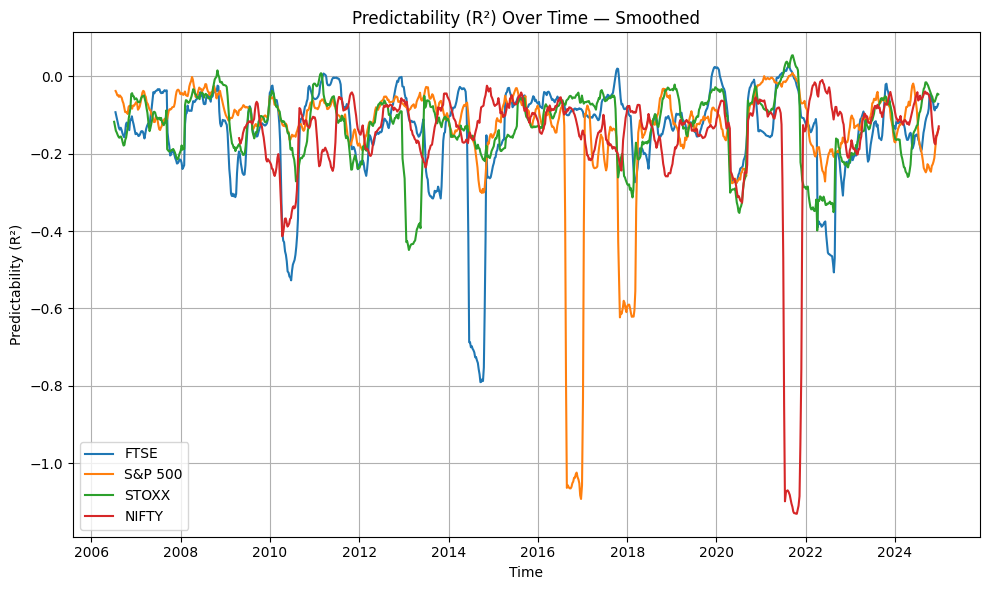

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_predictability(results_dict):

    plt.figure(figsize=(10,6))

    for name, df in results_dict.items():

        # Smooth R² (important for clarity)
        smooth = df['predictability'].rolling(20).mean()

        plt.plot(df['date'], smooth, label=name)

    plt.title("Predictability (R²) Over Time — Smoothed")
    plt.xlabel("Time")
    plt.ylabel("Predictability (R²)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ✅ Run it
plot_predictability({
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
})

/tmp/ipykernel_2615/3731725295.py:36: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



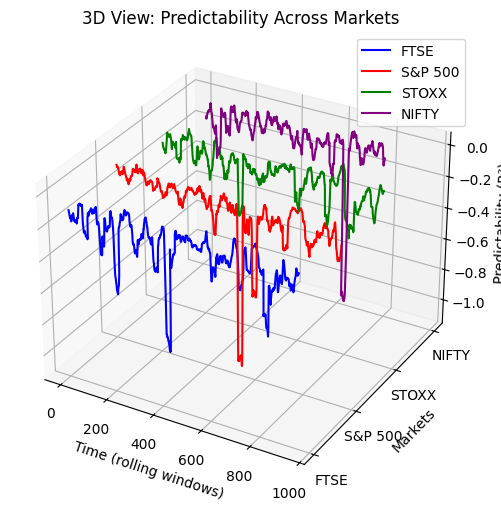

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_3d_predictability(markets_dict):

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['blue', 'red', 'green', 'purple']

    for i, (name, df) in enumerate(markets_dict.items()):

        data = df['predictability'].values

        # ✅ Smooth for clarity
        smooth = pd.Series(data).rolling(20).mean()

        x = np.arange(len(smooth))   # time
        y = np.full(len(smooth), i)  # market index
        z = smooth.values            # predictability

        ax.plot(x, y, z, color=colors[i], label=name)

    # ✅ Labels
    ax.set_xlabel("Time (rolling windows)")
    ax.set_ylabel("Markets")
    ax.set_zlabel("Predictability (R²)")

    ax.set_yticks(range(len(markets_dict)))
    ax.set_yticklabels(list(markets_dict.keys()))

    ax.set_title("3D View: Predictability Across Markets")

    ax.legend()

    plt.tight_layout()
    plt.show()


# ✅ Run it
plot_3d_predictability({
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
})

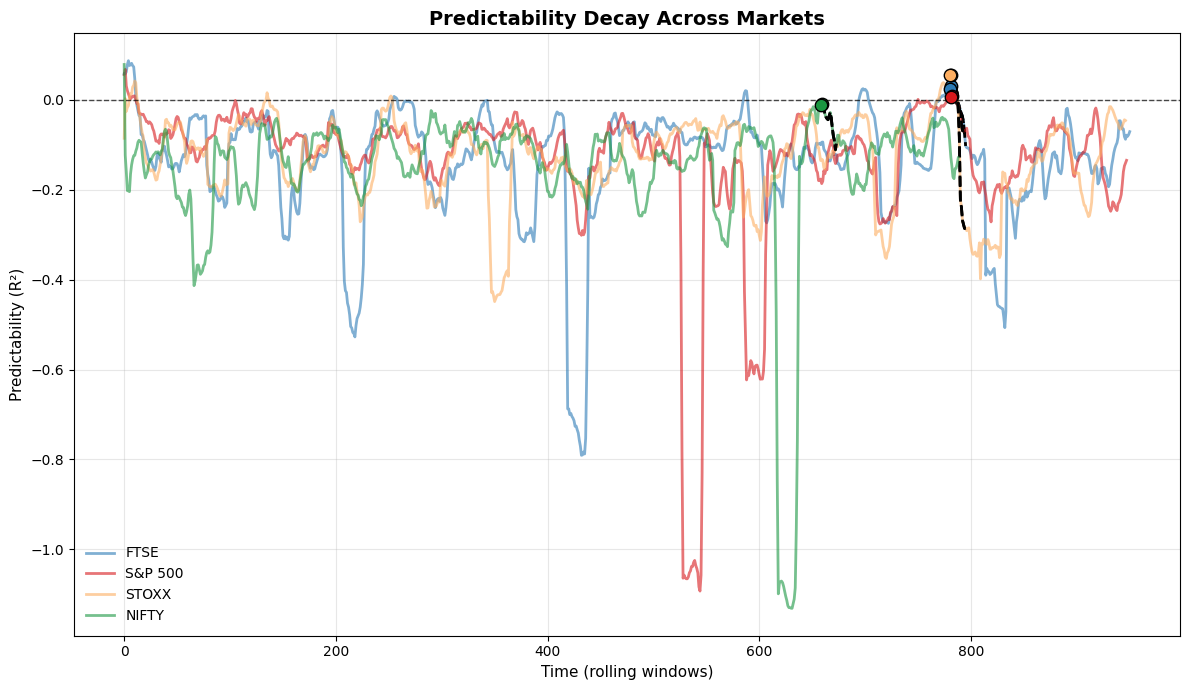

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_decay_all_markets(markets_dict):

    plt.figure(figsize=(12,7))

    # ✅ Define colors for consistency
    colors = {
        "FTSE": "#2C7BB6",      # blue
        "S&P 500": "#D7191C",   # red
        "STOXX": "#FDAE61",     # orange
        "NIFTY": "#1A9641"      # green
    }

    # ==============================
    # ✅ LOOP THROUGH MARKETS
    # ==============================
    for name, df in markets_dict.items():

        r2 = df['predictability'].values

        # ✅ Smooth series (important)
        smooth = pd.Series(r2).rolling(20, min_periods=1).mean().values

        # ✅ Plot main line
        plt.plot(
            smooth,
            color=colors[name],
            linewidth=2,
            alpha=0.6,
            label=name
        )

        # ==============================
        # ✅ PEAK DETECTION
        # ==============================
        peaks = []

        for i in range(20, len(smooth) - 20):

            if (
                smooth[i] > np.mean(smooth[i-5:i]) and
                smooth[i] > np.mean(smooth[i+1:i+6]) and
                smooth[i] > -0.1   # ignore weak noise peaks
            ):
                peaks.append(i)

        # ✅ Keep only strongest peaks (clean)
        peaks = sorted(peaks, key=lambda x: smooth[x], reverse=True)[:2]

        # ==============================
        # ✅ PLOT PEAKS + DECAY
        # ==============================
        for peak_idx in peaks:

            peak_val = smooth[peak_idx]

            # ✅ Mark peak
            plt.scatter(
                peak_idx,
                peak_val,
                color=colors[name],
                edgecolor='black',
                s=80,
                zorder=5
            )

            # ✅ Draw decay line
            end = min(len(smooth), peak_idx + 15)

            plt.plot(
                np.arange(peak_idx, end),
                smooth[peak_idx:end],
                linestyle='--',
                color='black',
                linewidth=2
            )

    # ==============================
    # ✅ FINAL TOUCHES
    # ==============================
    plt.axhline(
        0,
        linestyle='--',
        color='black',
        linewidth=1,
        alpha=0.7
    )

    plt.title("Predictability Decay Across Markets", fontsize=14, weight='semibold')
    plt.xlabel("Time (rolling windows)", fontsize=11)
    plt.ylabel("Predictability (R²)", fontsize=11)

    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)

    plt.tight_layout()

    # ✅ Save publication-quality file
    plt.savefig("predictability_decay_multi_market.png", dpi=300, bbox_inches='tight')

    plt.show()


# ==============================
# ✅ RUN THE FUNCTION
# ==============================
plot_decay_all_markets({
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
})

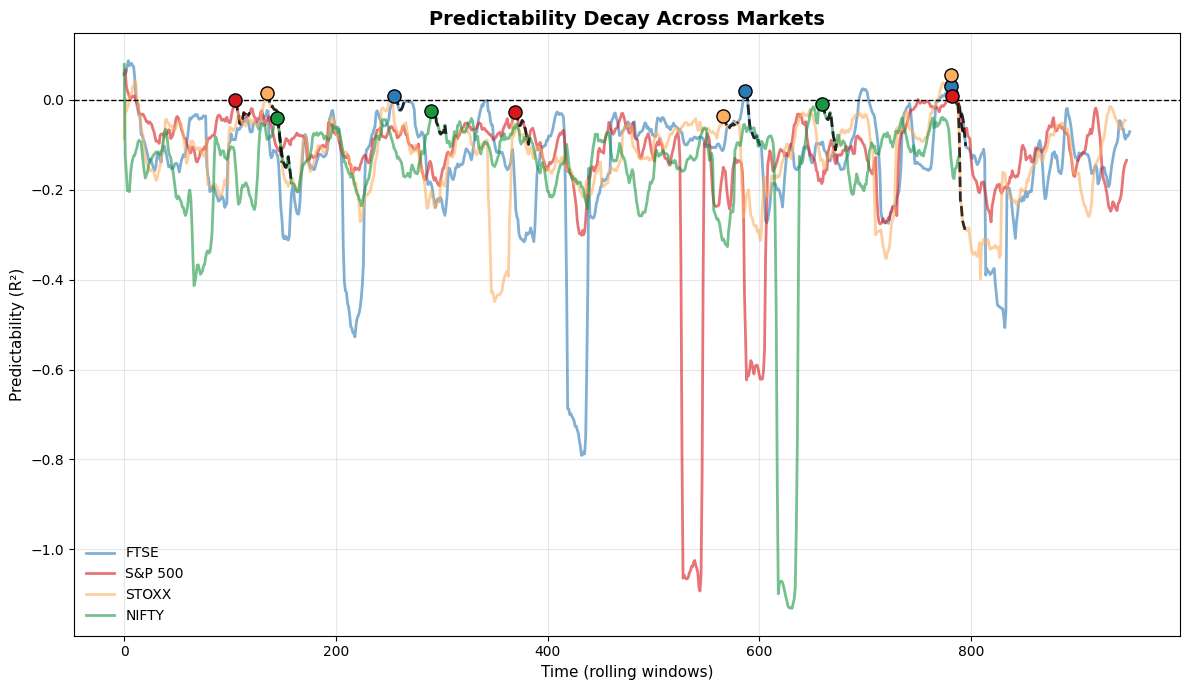

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_decay_all_markets(markets_dict):

    plt.figure(figsize=(12,7))

    # ✅ Consistent colors
    colors = {
        "FTSE": "#2C7BB6",      # blue
        "S&P 500": "#D7191C",   # red
        "STOXX": "#FDAE61",     # orange
        "NIFTY": "#1A9641"      # green
    }

    # ==============================
    # ✅ LOOP THROUGH MARKETS
    # ==============================
    for name, df in markets_dict.items():

        r2 = df['predictability'].values

        # ✅ Smooth (important)
        smooth = pd.Series(r2).rolling(20, min_periods=1).mean().values

        # ✅ Plot main line
        plt.plot(
            smooth,
            color=colors[name],
            linewidth=2,
            alpha=0.6,
            label=name
        )

        # ==============================
        # ✅ PEAK DETECTION (ALL PEAKS)
        # ==============================
        peaks = []

        for i in range(20, len(smooth)-20):

            if (
                smooth[i] > np.mean(smooth[i-5:i]) and
                smooth[i] > np.mean(smooth[i+1:i+6]) and
                smooth[i] > -0.1   # filter weak peaks
            ):
                peaks.append(i)

        # ==============================
        # ✅ SELECT PEAKS FROM DIFFERENT TIME ZONES
        # ==============================
        n = len(smooth)

        zones = [
            (0, n//3),             # early
            (n//3, 2*n//3),        # middle
            (2*n//3, n)            # late
        ]

        selected_peaks = []

        for start, end in zones:
            zone_peaks = [p for p in peaks if start <= p < end]

            if len(zone_peaks) > 0:
                best_peak = max(zone_peaks, key=lambda x: smooth[x])
                selected_peaks.append(best_peak)

        # ==============================
        # ✅ PLOT PEAKS + DECAY
        # ==============================
        for peak_idx in selected_peaks:

            peak_val = smooth[peak_idx]

            # ✅ peak marker
            plt.scatter(
                peak_idx,
                peak_val,
                color=colors[name],
                edgecolor='black',
                s=90,
                zorder=5
            )

            # ✅ decay line
            end = min(len(smooth), peak_idx + 15)

            plt.plot(
                np.arange(peak_idx, end),
                smooth[peak_idx:end],
                linestyle='--',
                color='black',
                linewidth=2,
                alpha=0.8
            )

    # ==============================
    # ✅ FINAL FORMATTING
    # ==============================
    plt.axhline(0, linestyle='--', color='black', linewidth=1)

    plt.title("Predictability Decay Across Markets", fontsize=14, weight='semibold')
    plt.xlabel("Time (rolling windows)", fontsize=11)
    plt.ylabel("Predictability (R²)", fontsize=11)

    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)

    plt.tight_layout()

    # ✅ Save high-quality figure
    plt.savefig("predictability_decay_multi_market_final.png", dpi=300, bbox_inches='tight')

    plt.show()


# ==============================
# ✅ RUN FUNCTION
# ==============================
plot_decay_all_markets({
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
})

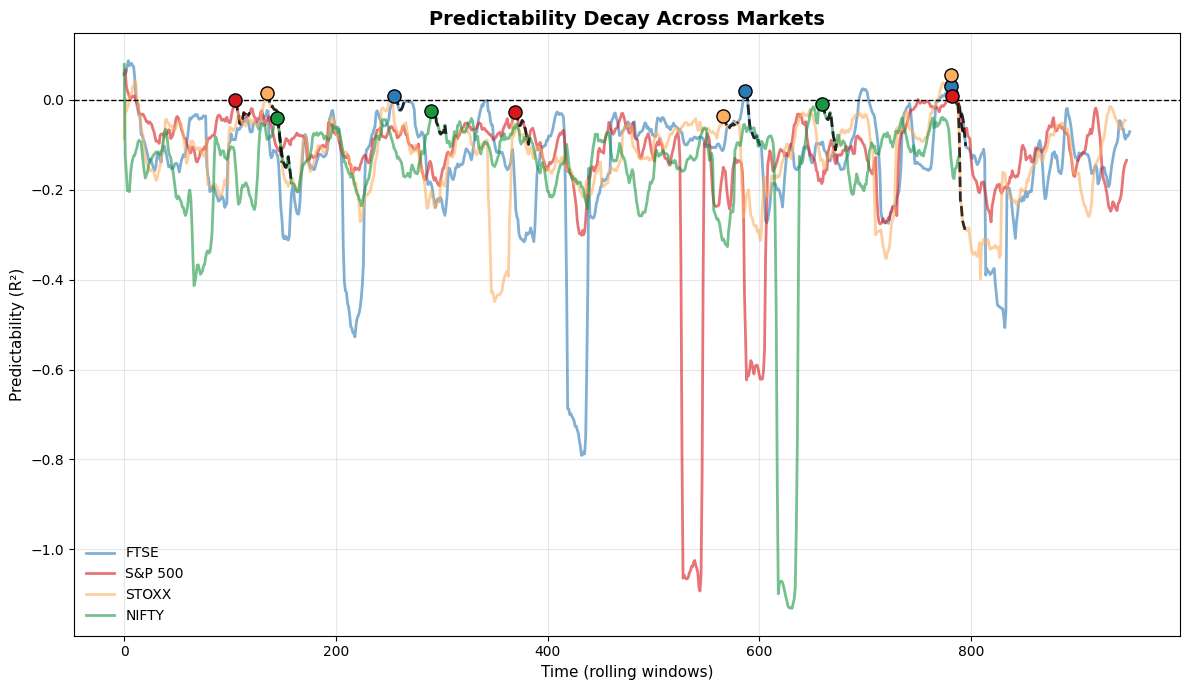

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_decay_all_markets(markets_dict):

    plt.figure(figsize=(12,7))

    # ✅ Consistent colors
    colors = {
        "FTSE": "#2C7BB6",      # blue
        "S&P 500": "#D7191C",   # red
        "STOXX": "#FDAE61",     # orange
        "NIFTY": "#1A9641"      # green
    }

    # ==============================
    # ✅ LOOP THROUGH MARKETS
    # ==============================
    for name, df in markets_dict.items():

        r2 = df['predictability'].values

        # ✅ Smooth (important)
        smooth = pd.Series(r2).rolling(20, min_periods=1).mean().values

        # ✅ Plot main line
        plt.plot(
            smooth,
            color=colors[name],
            linewidth=2,
            alpha=0.6,
            label=name
        )

        # ==============================
        # ✅ PEAK DETECTION (ALL PEAKS)
        # ==============================
        peaks = []

        for i in range(20, len(smooth)-20):

            if (
                smooth[i] > np.mean(smooth[i-5:i]) and
                smooth[i] > np.mean(smooth[i+1:i+6]) and
                smooth[i] > -0.1   # filter weak peaks
            ):
                peaks.append(i)

        # ==============================
        # ✅ SELECT PEAKS FROM DIFFERENT TIME ZONES
        # ==============================
        n = len(smooth)

        zones = [
            (0, n//3),             # early
            (n//3, 2*n//3),        # middle
            (2*n//3, n)            # late
        ]

        selected_peaks = []

        for start, end in zones:
            zone_peaks = [p for p in peaks if start <= p < end]

            if len(zone_peaks) > 0:
                best_peak = max(zone_peaks, key=lambda x: smooth[x])
                selected_peaks.append(best_peak)

        # ==============================
        # ✅ PLOT PEAKS + DECAY
        # ==============================
        for peak_idx in selected_peaks:

            peak_val = smooth[peak_idx]

            # ✅ peak marker
            plt.scatter(
                peak_idx,
                peak_val,
                color=colors[name],
                edgecolor='black',
                s=90,
                zorder=5
            )

            # ✅ decay line
            end = min(len(smooth), peak_idx + 15)

            plt.plot(
                np.arange(peak_idx, end),
                smooth[peak_idx:end],
                linestyle='--',
                color='black',
                linewidth=2,
                alpha=0.8
            )

    # ==============================
    # ✅ FINAL FORMATTING
    # ==============================
    plt.axhline(0, linestyle='--', color='black', linewidth=1)

    plt.title("Predictability Decay Across Markets", fontsize=14, weight='semibold')
    plt.xlabel("Time (rolling windows)", fontsize=11)
    plt.ylabel("Predictability (R²)", fontsize=11)

    plt.grid(True, alpha=0.3)
    plt.legend(frameon=False)

    plt.tight_layout()

    # ✅ Save high-quality figure
    plt.savefig("predictability_decay_multi_market_final.png", dpi=300, bbox_inches='tight')

    plt.show()


# ==============================
# ✅ RUN FUNCTION
# ==============================
plot_decay_all_markets({
    "FTSE": results_rf,
    "S&P 500": results_sp_rf,
    "STOXX": results_eu_rf,
    "NIFTY": results_india_rf
})

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# ==============================
# DELETE OLD FILE (SAFE)
# ==============================
file_name = "journal_results.xlsx"

if os.path.exists(file_name):
    os.remove(file_name)
    print("✅ Old file deleted")

# ==============================
# SIGNIFICANCE STARS
# ==============================
def stars(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''

def format_coef(val, p):
    return f"{val:.3f}{stars(p)}"

# ==============================
# YOUR DATA
# ==============================
markets = {
    "FTSE": results,
    "S&P 500": results_sp,
    "STOXX": results_eu,
    "NIFTY": results_india
}

# ==============================
# ✅ TABLE 1 — MAIN RESULTS (Journal Style)
# ==============================
table_main = []

for name, df in markets.items():

    r2 = df['predictability'].dropna()
    acc = df['accuracy'].dropna()

    # ---- TESTS ----
    r2_stat, r2_p = stats.ttest_1samp(r2, 0)
    acc_stat, acc_p = stats.ttest_1samp(acc, 0.5)

    # ---- MEANS ----
    r2_mean = r2.mean()
    acc_mean = acc.mean()

    # ---- CONFIDENCE INTERVALS ----
    r2_ci = stats.t.interval(0.95, len(r2)-1, loc=r2_mean, scale=stats.sem(r2))
    acc_ci = stats.t.interval(0.95, len(acc)-1, loc=acc_mean, scale=stats.sem(acc))

    # ✅ CORRECT FORMAT (NO ERROR)
    table_main.append({
        "Market": name,
        "Mean R²": format_coef(r2_mean, r2_p),
        "R² CI": f"[{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]",
        "Accuracy": format_coef(acc_mean, acc_p),
        "Accuracy CI": f"[{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]"
    })

table_main = pd.DataFrame(table_main)

# ==============================
# ✅ TABLE 2 — DECAY METRICS
# ==============================
table_decay = []

for name, df in markets.items():

    r2 = df['predictability']
    peak = r2.max()
    peak_idx = r2.idxmax()

    after = r2.loc[peak_idx:]
    min_val = after.min()
    decay = peak - min_val

    half_val = peak * 0.5
    idx = after[after <= half_val].index
    half_life = idx[0] - peak_idx if len(idx) > 0 else np.nan

    table_decay.append({
        "Market": name,
        "Peak R²": round(peak, 3),
        "Min After Peak": round(min_val, 3),
        "Decay": round(decay, 3),
        "Half-Life": half_life
    })

table_decay = pd.DataFrame(table_decay)

# ==============================
# SAVE TO EXCEL
# ==============================
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    table_main.to_excel(writer, sheet_name="Main_Results", index=False)
    table_decay.to_excel(writer, sheet_name="Decay_Metrics", index=False)

print("✅ SUCCESS — File saved as:", file_name)

# ==============================
# DOWNLOAD (for Colab/Jupyter)
# ==============================
try:
    from google.colab import files
    files.download(file_name)
except:
    print("✅ File ready in working directory")

✅ SUCCESS — File saved as: journal_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =========================================
# ✅ DELETE OLD FILE
# =========================================
file_name = "journal_results_clean.xlsx"

if os.path.exists(file_name):
    os.remove(file_name)
    print("✅ Old incorrect file deleted")

# =========================================
# ✅ SIGNIFICANCE STARS
# =========================================
def stars(p):
    if p < 0.01:
        return '***'
    elif p < 0.05:
        return '**'
    elif p < 0.10:
        return '*'
    else:
        return ''

def format_coef(val, p):
    return f"{val:.3f}{stars(p)}"

# =========================================
# ✅ DATA
# =========================================
markets = {
    "FTSE": results,
    "S&P 500": results_sp,
    "STOXX": results_eu,
    "NIFTY": results_india
}

# =========================================
# ✅ TABLE 1 — MAIN RESULTS (FIXED CI)
# =========================================
table_main_rows = []

for name, df in markets.items():

    r2 = df['predictability'].dropna()
    acc = df['accuracy'].dropna()

    # ---- TESTS ----
    r2_stat, r2_p = stats.ttest_1samp(r2, 0)
    acc_stat, acc_p = stats.ttest_1samp(acc, 0.5)

    # ---- MEANS ----
    r2_mean = r2.mean()
    acc_mean = acc.mean()

    # ---- CONFIDENCE INTERVALS ----
    r2_ci = stats.t.interval(0.95, len(r2)-1, loc=r2_mean, scale=stats.sem(r2))
    acc_ci = stats.t.interval(0.95, len(acc)-1, loc=acc_mean, scale=stats.sem(acc))

    # ✅ ✅ CORRECT FORMAT (FINAL FIX)
    r2_ci_str = f"[{r2_ci[0]:.3f}, {r2_ci[1]:.3f}]"
    acc_ci_str = f"[{acc_ci[0]:.3f}, {acc_ci[1]:.3f}]"

    table_main_rows.append({
        "Market": name,
        "Mean R²": format_coef(r2_mean, r2_p),
        "R² CI": r2_ci_str,
        "Accuracy": format_coef(acc_mean, acc_p),
        "Accuracy CI": acc_ci_str
    })

table_main = pd.DataFrame(table_main_rows)

# =========================================
# ✅ TABLE 2 — DECAY METRICS
# =========================================
table_decay_rows = []

for name, df in markets.items():

    r2 = df['predictability']

    peak = r2.max()
    peak_idx = r2.idxmax()

    after = r2.loc[peak_idx:]
    min_val = after.min()
    decay = peak - min_val

    half_val = peak * 0.5
    idx = after[after <= half_val].index
    half_life = idx[0] - peak_idx if len(idx) > 0 else np.nan

    table_decay_rows.append({
        "Market": name,
        "Peak R²": round(peak, 3),
        "Min After Peak": round(min_val, 3),
        "Decay Magnitude": round(decay, 3),
        "Half-Life": int(half_life) if not np.isnan(half_life) else ""
    })

table_decay = pd.DataFrame(table_decay_rows)

# =========================================
# ✅ SAVE TO EXCEL
# =========================================
with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    table_main.to_excel(writer, sheet_name="Main_Results", index=False)
    table_decay.to_excel(writer, sheet_name="Decay_Metrics", index=False)

print("✅ FINAL SUCCESS → Clean journal tables saved:", file_name)

✅ Old incorrect file deleted
✅ FINAL SUCCESS → Clean journal tables saved: journal_results_clean.xlsx


In [ ]:
from google.colab import files
files.download("journal_results_clean.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("predictability_journal_figure.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

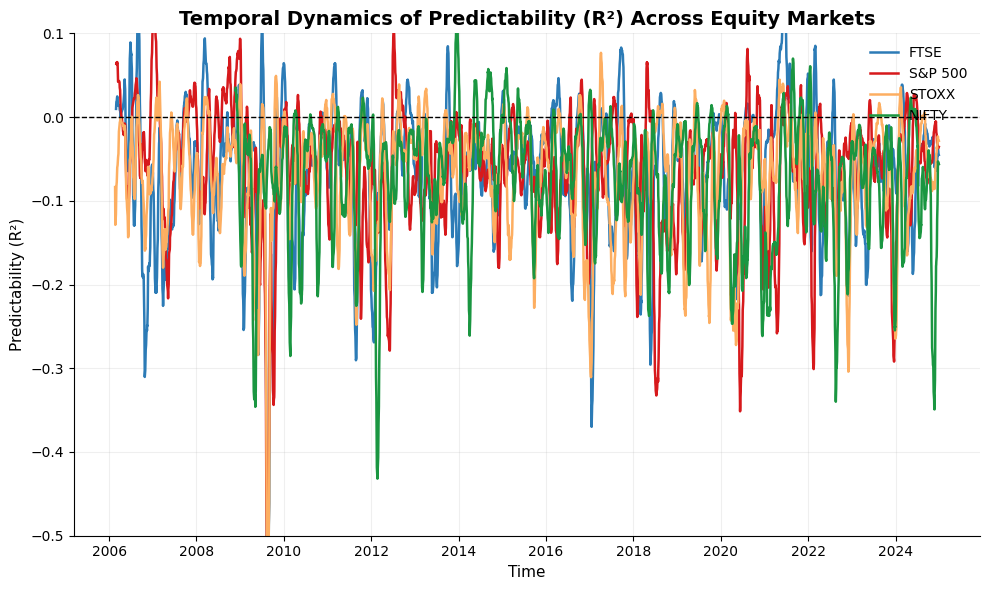

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ==============================
# ✅ DATA
# ==============================
markets = {
    "FTSE": results,
    "S&P 500": results_sp,
    "STOXX": results_eu,
    "NIFTY": results_india
}

# Professional colour palette
colors = {
    "FTSE": "#2C7BB6",     # blue
    "S&P 500": "#D7191C", # red
    "STOXX": "#FDAE61",   # orange
    "NIFTY": "#1A9641"   # green
}

# ==============================
# ✅ CREATE FIGURE
# ==============================
plt.figure(figsize=(10, 6))

for name, df in markets.items():

    # ✅ Smooth predictability (important for clarity)
    smooth = df['predictability'].rolling(20, min_periods=1).mean()

    plt.plot(
        df['date'],
        smooth,
        label=name,
        color=colors[name],
        linewidth=1.8
    )

# ==============================
# ✅ REFERENCE LINE (CRITICAL)
# ==============================
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

# ==============================
# ✅ FORMATTING (JOURNAL STYLE)
# ==============================
plt.title(
    "Temporal Dynamics of Predictability (R²) Across Equity Markets",
    fontsize=14,
    weight='semibold'
)

plt.xlabel("Time", fontsize=11)
plt.ylabel("Predictability (R²)", fontsize=11)

# ✅ LIGHT GRID (LESS DISTRACTION)
plt.grid(True, alpha=0.2)

# ✅ REMOVE UNNECESSARY BORDERS
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ✅ CLEAN LEGEND
plt.legend(frameon=False, loc='upper right')

# ✅ IMPORTANT: CONTROL SCALE
plt.ylim(-0.5, 0.1)

# ==============================
# ✅ SAVE FIGURES
# ==============================

# High-quality (for journal submission)
plt.savefig(
    "predictability_figure_HD.png",
    dpi=300,
    bbox_inches='tight'
)

# Lightweight (for phone/download)
plt.savefig(
    "predictability_figure_light.png",
    dpi=150,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# ==============================
# ✅ DOWNLOAD (FOR COLAB)
# ==============================
try:
    from google.colab import files
    files.download("predictability_figure_light.png")  # download small version
except:
    print("✅ Files saved locally: predictability_figure_HD.png & light version")

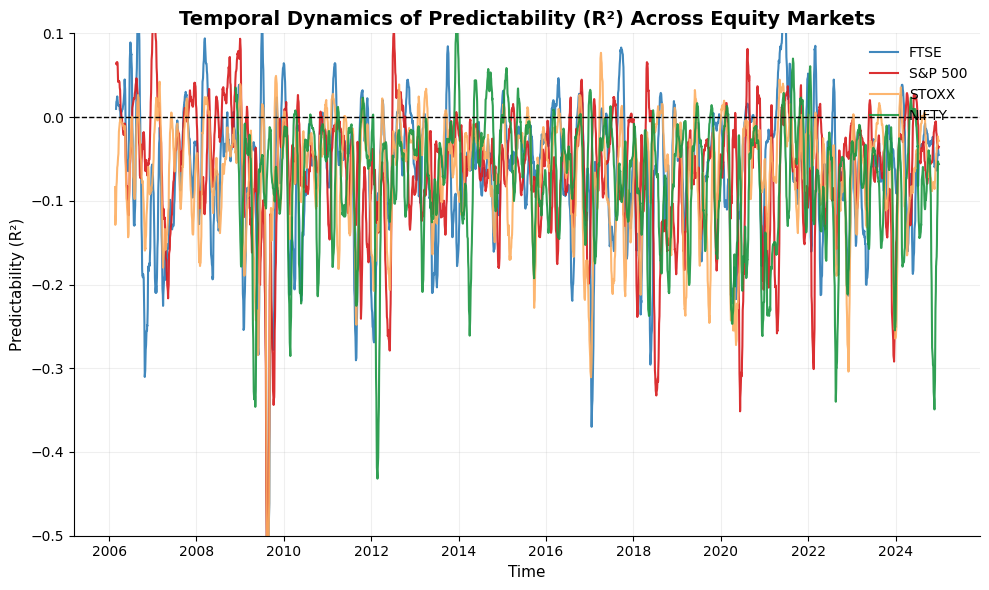

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =====================================
# ✅ USE CLEAN JOURNAL STYLE
# =====================================
plt.style.use('default')

# =====================================
# ✅ DATA
# =====================================
markets = {
    "FTSE": results,
    "S&P 500": results_sp,
    "STOXX": results_eu,
    "NIFTY": results_india
}

# ✅ Professional colors (colorblind-friendly)
colors = {
    "FTSE": "#2C7BB6",
    "S&P 500": "#D7191C",
    "STOXX": "#FDAE61",
    "NIFTY": "#1A9641"
}

# =====================================
# ✅ CREATE FIGURE
# =====================================
plt.figure(figsize=(10, 6))

for name, df in markets.items():

    # ✅ Smooth data (very important)
    smooth = df['predictability'].rolling(20, min_periods=1).mean()

    plt.plot(
        df['date'],
        smooth,
        label=name,
        color=colors[name],
        linewidth=1.5,   # slightly thinner
        alpha=0.9        # slight transparency
    )

# =====================================
# ✅ ZERO REFERENCE LINE
# =====================================
plt.axhline(
    y=0,
    color='black',
    linestyle='--',
    linewidth=1
)

# =====================================
# ✅ TITLES & LABELS
# =====================================
plt.title(
    "Temporal Dynamics of Predictability (R²) Across Equity Markets",
    fontsize=14,
    weight='semibold'
)

plt.xlabel("Time", fontsize=11)
plt.ylabel("Predictability (R²)", fontsize=11)

# =====================================
# ✅ CLEAN GRID
# =====================================
plt.grid(True, alpha=0.2)

# =====================================
# ✅ REMOVE EXTRA BORDERS
# =====================================
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =====================================
# ✅ LEGEND (CLEAN)
# =====================================
plt.legend(
    frameon=False,
    loc='upper right',
    fontsize=10
)

# =====================================
# ✅ CONTROL SCALE (VERY IMPORTANT)
# =====================================
plt.ylim(-0.5, 0.1)

# =====================================
# ✅ SAVE FIGURES
# =====================================

# 🔥 High-quality version (for journal submission)
plt.savefig(
    "predictability_figure_HD.png",
    dpi=300,
    bbox_inches='tight'
)

# ✅ Light version (for phone / safe download)
plt.savefig(
    "predictability_figure_light.png",
    dpi=150,
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()

# =====================================
# ✅ DOWNLOAD FILE (SAFE)
# =====================================
try:
    from google.colab import files

    # ✅ download lighter version (prevents crash)
    files.download("predictability_figure_light.png")

except:
    print("✅ Files saved locally:")
    print(" - predictability_figure_HD.png")
    print(" - predictability_figure_light.png")